# **BASELINE MODEL**

In this notebook, we will create the baseline model with no physics-informed loss function and a PINN with the modified loss function to account for the physics. We start off with our usual imports,

In [17]:
# PyTorch imports,
import torch # <-- PyTorch
from torch.nn import Linear
from torch.utils.data import Dataset, DataLoader # <-- Wrappers for the data.
from torch.optim import Adam
import torch.nn.functional as F
import torchvision
from torchinfo import summary

# Importing,
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import h5py
import sys

# Printing versions,
print("System Version:", sys.version)
print("PyTorch version", torch.__version__)
print("Torch Vision version", torchvision.__version__)
print("Numpy version", np.__version__)
print("Pandas version", pd.__version__)

System Version: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
PyTorch version 2.6.0+cpu
Torch Vision version 0.21.0+cpu
Numpy version 1.26.4
Pandas version 2.2.2


### 1. Loading Data

In [10]:
class FlowDataset(Dataset):
    """Class container for the training data."""

    def __init__(self, split="train", X_min=None, X_max=None, y_min=None, y_max=None):
        """Loads, scales (using min-max) and converts the data into Tensors."""

        # Loading,
        if split == "test":
            Xy = np.load("data_test.npy")
        elif split == "validation":
            Xy = np.load("data_validation.npy")
        else:
            Xy = np.load("data_train.npy")

        self.n_samples = Xy.shape[1]
        self.X, self.y = Xy[0], Xy[1]

        # Performing min-max scaling,
        self.X = (self.X - X_min)/(X_max - X_min)
        self.y = (self.y - y_min)/(y_max - y_min)

        # Converting to Tensors (float32 type),
        self.X = torch.from_numpy(self.X.astype(np.float32))
        self.y = torch.from_numpy(self.y.astype(np.float32))

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    
    def __len__(self):
        return self.n_samples

# For scaling,
Xy_train = np.load("data_train.npy")
X_train, y_train = Xy_train[0], Xy_train[1]
X_min, X_max = np.min(X_train), np.max(X_train)
y_min, y_max = np.min(y_train), np.max(y_train)

# Loading training, testing and validation data,
train_data = FlowDataset("train", X_min, X_max, y_min, y_max)
test_data = FlowDataset("test", X_min, X_max, y_min, y_max)
val_data = FlowDataset("validation", X_min, X_max, y_min, y_max)

# Creating dataloaders,
BATCH_SIZE = 128
train_loader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(dataset=val_data, batch_size=BATCH_SIZE, shuffle=True)

Inspecting the data,

In [11]:
for (X, y) in train_loader:
    print(f"X: {X.shape}, y: {y.shape}")
    break

X: torch.Size([128, 3]), y: torch.Size([128, 3])


### 2. Model Creation

In this section we create the model architecture for the PINN. There is nothing too special about the architecture of vanilla PINNs, they are mid-sized (maybe towards the smaller end) MLPS. The real _magic_ of PINNs are their physics informed loss functions. For our project, we will use `8` fully-connected hidden layers with each having `64` neurons. 

In [12]:
class Model(torch.nn.Module):
    """The neural network architecture."""

    def __init__(self):
        """Constuctor method. Builds the neural network."""
        super(Model, self).__init__()

        # Creating model layers,
        self.fc1 = Linear(in_features=3, out_features=128)
        self.fc2 = Linear(in_features=128, out_features=128)
        self.fc3 = Linear(in_features=128, out_features=128)
        self.fc4 = Linear(in_features=128, out_features=3)

    def forward(self, x):
        """Defines the forward propagation of the neural network."""

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))

        return x

Testing the forward propagation using `torchinfo`,

In [13]:
# Creating the neural network,
model = Model()
summary(model, input_size=(BATCH_SIZE, 3))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [128, 3]                  --
├─Linear: 1-1                            [128, 128]                512
├─Linear: 1-2                            [128, 128]                16,512
├─Linear: 1-3                            [128, 128]                16,512
├─Linear: 1-4                            [128, 3]                  387
Total params: 33,923
Trainable params: 33,923
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 4.34
Input size (MB): 0.00
Forward/backward pass size (MB): 0.40
Params size (MB): 0.14
Estimated Total Size (MB): 0.53

### 3. Model Training (Baseline)

For the baseline model, we train it with `Adam` optimiser minimising the `MSE` loss until it reaches the threshold for overfitting.

In [14]:
# Hyperparameters,
patience = 5
max_epochs = 50
lr = 1e-3

# Enabling CUDA (if possible),
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Training on: {device}")

# Creating the optimiser,
optimiser = Adam(model.parameters(), lr=lr)

# Specifying the loss function,
loss_fn = torch.nn.MSELoss()

"""TRAINING LOOP"""
train_losses = []
val_losses = []
best_val_loss = float('inf')  
epochs_no_improve = 0
for epoch in range(1, max_epochs+1):

    """================= TRAIN ================="""
    model.train() # <-- Training mode.
    train_running_loss = 0.0

    # Batch loop,
    for (X, y) in train_loader:
        optimiser.zero_grad() # Clear gradients,
        X, y = X.to(device), y.to(device) # Moving tensors to training device.
        y_pred = model(X) # Forward pass.
        loss = loss_fn(y_pred, y) # Computing loss.
        loss.backward() # Backward pass.
        optimiser.step() # Parameter update.

        # Tracking loss,
        train_running_loss += loss.item()

    train_loss = train_running_loss/len(train_loader)
    train_losses.append(train_loss)

    """================= VALIDATION ================="""
    model.eval() # <-- Switching to evaluation mode.
    val_running_loss = 0.0

    # Not tracking gradients,
    with torch.no_grad():
        for X_val, y_val in val_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            y_pred = model(X_val)
            loss = loss_fn(y_pred, y_val)
            val_running_loss += loss.item()

    val_loss = val_running_loss / len(val_loader)
    val_losses.append(val_loss)

    # Printing,
    print(f"Epoch {epoch} | training_loss: {train_loss:.6f} | validation_loss: {val_loss:.6f}")

    """ ================= EARLY STOPPING MECHANISM ================="""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0

        # Saving checkpoint,
        torch.save(model.state_dict(), "best_model.pth")

    else:
        epochs_no_improve += 1
    if epochs_no_improve >= patience:
        print("TRAINING HALTED.")
        break

Training on: cpu
Epoch 1 | training_loss: 0.024794 | validation_loss: 0.006825
Epoch 2 | training_loss: 0.005775 | validation_loss: 0.004433
Epoch 3 | training_loss: 0.004227 | validation_loss: 0.003891
Epoch 4 | training_loss: 0.003663 | validation_loss: 0.003123
Epoch 5 | training_loss: 0.003196 | validation_loss: 0.002888
Epoch 6 | training_loss: 0.002866 | validation_loss: 0.002782
Epoch 7 | training_loss: 0.002702 | validation_loss: 0.002448
Epoch 8 | training_loss: 0.002632 | validation_loss: 0.002697
Epoch 9 | training_loss: 0.002564 | validation_loss: 0.002417
Epoch 10 | training_loss: 0.002531 | validation_loss: 0.002513
Epoch 11 | training_loss: 0.002511 | validation_loss: 0.002540
Epoch 12 | training_loss: 0.002472 | validation_loss: 0.002419
Epoch 13 | training_loss: 0.002459 | validation_loss: 0.002322
Epoch 14 | training_loss: 0.002448 | validation_loss: 0.002413
Epoch 15 | training_loss: 0.002440 | validation_loss: 0.002370
Epoch 16 | training_loss: 0.002467 | validation

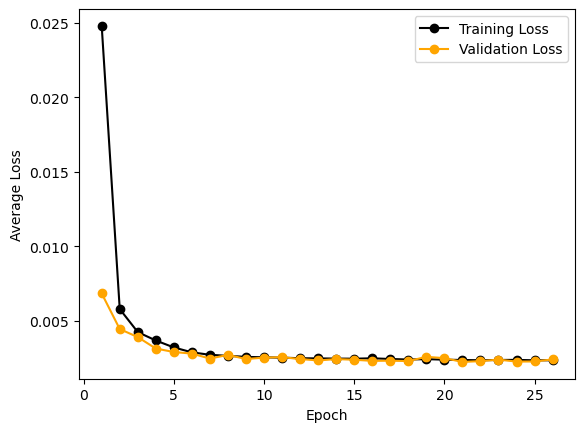

In [16]:
# Plotting,
epochs = np.arange(start=1, stop=len(train_losses)+1, step=1)
plt.plot(epochs, train_losses, marker="o", color="black", label="Training Loss")
plt.plot(epochs, val_losses, marker="o", color="orange", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.legend()
plt.show()

### 4. Model Prediction

Let us create a function for model inference,

In [ ]:
def predict(model, dataloader, device="cpu"):
    """This function performs model inference."""

    # Switch model to evaluation mode,
    model.eval()

    # Creating the predictions array,
    y_preds = []

    # Looping over all batches,
    with torch.no_grad():
        for X in dataloader:

            # Moving input tensor to training device,
            X = X.to(device).float()
    
            # Model forward pass,
            y_pred = model(X)
            y_pred = y_pred.cpu() # <-- Move to CPU.
            y_preds.append(y_pred)

    # Concatening batch predictions,
    y_preds = torch.cat(y_preds, dim=0)

    # Returning predictions,
    return y_preds

Now we generate the model predictions,

In [99]:
# Loading the required simulation data,
with h5py.File("cylinder_Re100.h5", "r") as file:
    t = file["t"][:]
    x = file["x"][:]
    y = file["y"][:]

X = np.stack([
    x.reshape(-1),
    y.reshape(-1),
    np.repeat(t[:, None], x.shape[1], axis=1).reshape(-1)
], axis=1)

# Creating dataloader,
sim_loader = DataLoader(X, batch_size=BATCH_SIZE, shuffle=False)

# Generating model predictions,
preds = predict(model, dataloader=sim_loader, device="cpu")

# Reverse scaling,
preds = preds*(X_max - X_min) + X_min

Now we have to convert our predictions `preds` from a Tensor to a NumPy arrays which represent the predicted velocity and pressure fields. We must ensure that their shapes are consistent with the original simulation data such that we can use them in the simulation suite. 

In [98]:
# Converting to correct format,
n_time_steps, n_nodes = 201,  82872
preds = preds.numpy()
preds = preds.reshape(n_time_steps, n_nodes, 3) # Reshaping.
u_pred, v_pred, p_pred = preds[:, :, 0], preds[:, :, 1], preds[:, :, 2] # Extracting predicted fields.

# Saving predictions,
np.save(file="u_pred_baseline.npy", arr=u_pred)
np.save(file="v_pred_baseline", arr=v_pred)
np.save(file="p_pred_baseline", arr=p_pred)